In [12]:
%load_ext autoreload
%autoreload 2

import cupy as cp
from utils.data_loader import ImagenetteDataLoader
from model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [2]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(224, 224)
)

len(train_loader), train_loader.get_image_shape()

(9469, (3, 224, 224))

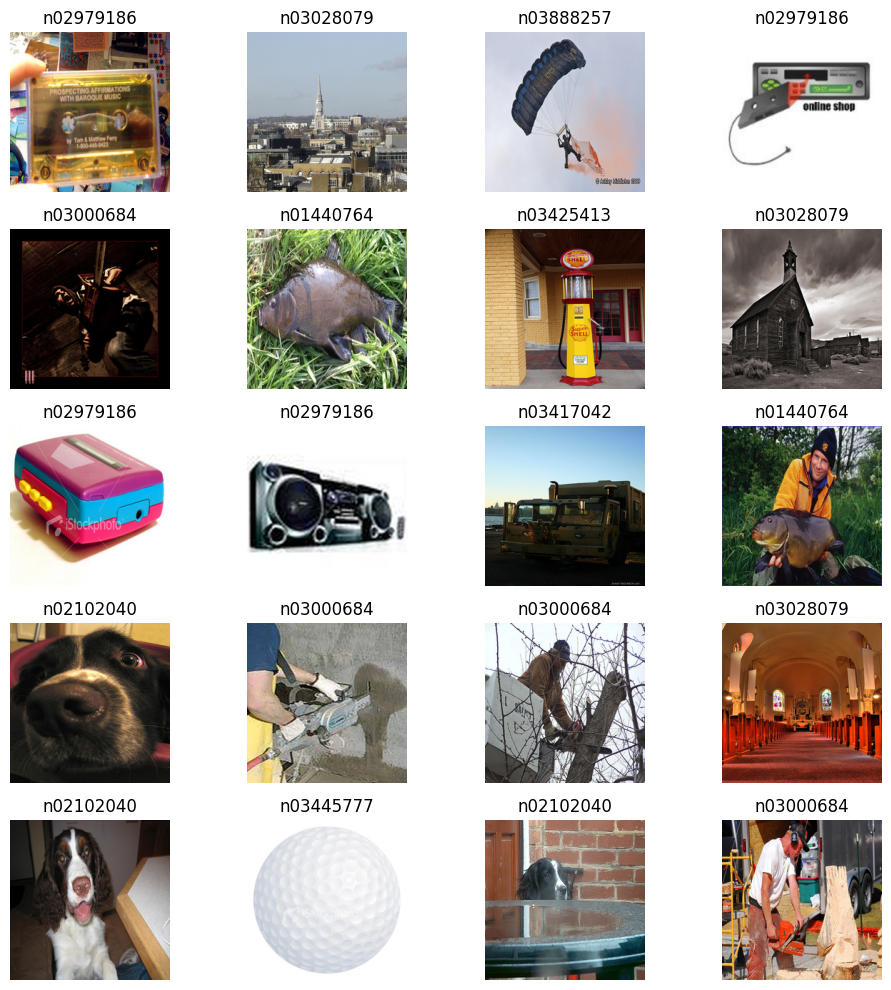

In [3]:
random_indices = cp.random.randint(0, len(train_loader), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [4]:
layer_definitions = [
    {"type": "Conv", "num_filters": 32, "num_channels": 3, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 3, "pool_width": 3, "stride": 2},
    {"type": "Conv", "num_filters": 16, "num_channels": 32, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "Conv", "num_filters": 8, "num_channels": 16, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "Flatten"},
    {"type": "ReLU", "input_size": 5408, "num_neurons": 512},
    {"type": "ReLU", "input_size": 512, "num_neurons": 256},
    {"type": "Softmax", "input_size": 256, "num_neurons": 10},
]

network = Network(layer_definitions=layer_definitions)

In [5]:
network.describe()

Network Architecture

Layer 1: ConvLayer
  Filters Shape: (32, 3, 3, 3)
  Parameters: 864

Layer 2: MaxPoolLayer
  Pool Shape: (3, 3) | Stride: 2

Layer 3: ConvLayer
  Filters Shape: (16, 32, 3, 3)
  Parameters: 4,608

Layer 4: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 5: ConvLayer
  Filters Shape: (8, 16, 3, 3)
  Parameters: 1,152

Layer 6: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 7: FlattenLayer
  Parameters: 0

Layer 8: ReluLayer
  Weights Shape: (5408, 512) | Biases Shape: (512,)
  Parameters: 2,769,408

Layer 9: ReluLayer
  Weights Shape: (512, 256) | Biases Shape: (256,)
  Parameters: 131,328

Layer 10: SoftmaxLayer
  Weights Shape: (256, 10) | Biases Shape: (10,)
  Parameters: 2,570

Total Parameters: 2,909,930


In [ ]:
batch_size = 10
learning_rate = 0.001
epochs = 10
train_num_batches = (len(train_loader) + batch_size - 1) // batch_size

for epoch in range(epochs):
    total_loss = 0.0

    for batch_idx, (x_batch, y_batch) in enumerate(
        train_loader.iter_batches(batch_size=batch_size, normalize=True, one_hot=True, shuffle=True),
        start=1
    ):
        outputs = network.forward(input=x_batch)
        y_pred = outputs[-1]

        error = y_pred - y_batch
        loss = network.cce_loss(y_pred=y_pred, y_true=y_batch).item()
        total_loss += loss

        network.backward(output_error=error, batch_size=x_batch.shape[0])
        network.update_parameters(learning_rate=learning_rate)

        if (batch_idx + 1) % 100 == 0 or batch_idx == train_num_batches:
            print(f"Epoch {epoch + 1}/{epochs}, Batch {batch_idx + 1}/{train_num_batches}, Avg Loss: {total_loss / batch_idx:.6f}")
        
    print(f"Epoch {epoch + 1}/{epochs} completed. Avg Loss: {total_loss / train_num_batches:.6f}")

Epoch 1/10, Batch 100/947, Avg Loss: 2.133799
Epoch 1/10, Batch 200/947, Avg Loss: 2.107533
Epoch 1/10, Batch 300/947, Avg Loss: 2.097012
Epoch 1/10, Batch 400/947, Avg Loss: 2.087279
Epoch 1/10, Batch 500/947, Avg Loss: 2.077427
Epoch 1/10, Batch 600/947, Avg Loss: 2.066629
Epoch 1/10, Batch 700/947, Avg Loss: 2.044997
Epoch 1/10, Batch 800/947, Avg Loss: 2.029632
Epoch 1/10, Batch 900/947, Avg Loss: 2.014511
Epoch 1/10, Batch 948/947, Avg Loss: 2.009631
Epoch 1/10 completed. Avg Loss: 2.009631
Epoch 2/10, Batch 100/947, Avg Loss: 1.859999
Epoch 2/10, Batch 200/947, Avg Loss: 1.835404
Epoch 2/10, Batch 300/947, Avg Loss: 1.829929
Epoch 2/10, Batch 400/947, Avg Loss: 1.815968
Epoch 2/10, Batch 500/947, Avg Loss: 1.811831
Epoch 2/10, Batch 600/947, Avg Loss: 1.810904
Epoch 2/10, Batch 700/947, Avg Loss: 1.807675
Epoch 2/10, Batch 800/947, Avg Loss: 1.797790
Epoch 2/10, Batch 900/947, Avg Loss: 1.791056
Epoch 2/10, Batch 948/947, Avg Loss: 1.789815
Epoch 2/10 completed. Avg Loss: 1.78981

In [9]:
test_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="val",
    target_size=(224, 224)
)

len(test_loader), test_loader.get_image_shape()

(3925, (3, 224, 224))

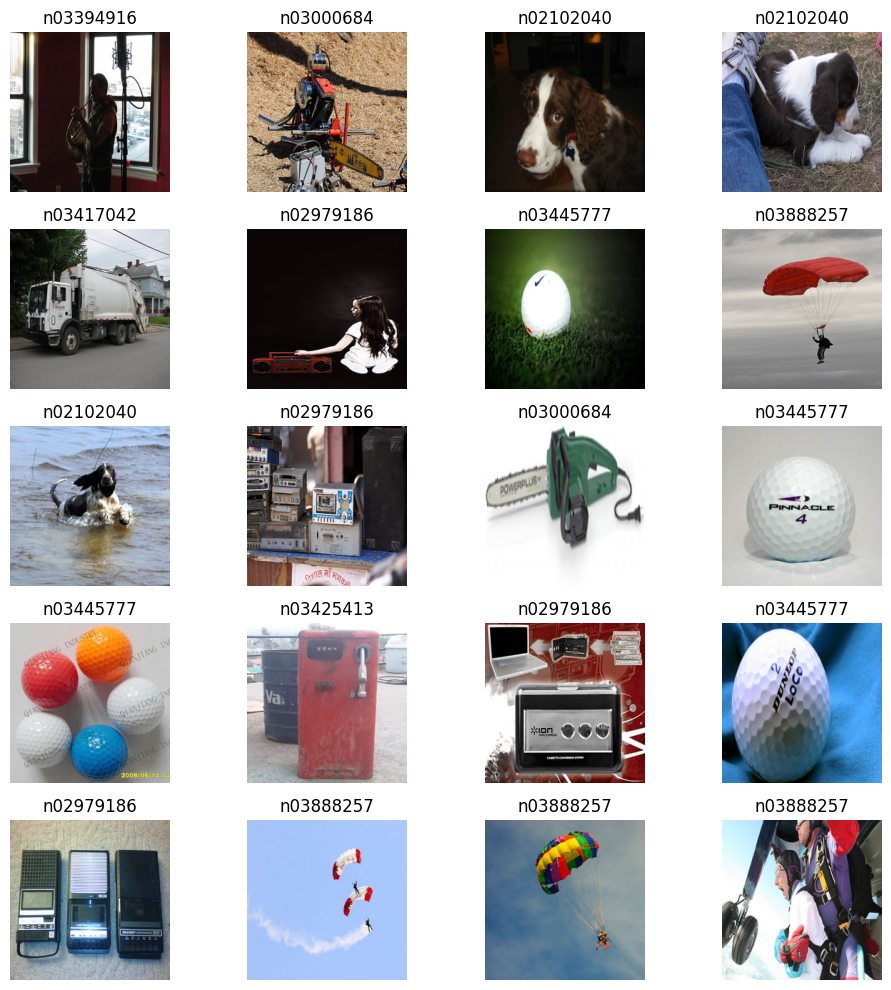

In [10]:
random_indices = cp.random.randint(0, len(test_loader), size=20)
test_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [11]:
correct_predictions = 0
num_test_samples = 0
test_num_batches = (len(test_loader) + batch_size - 1) // batch_size

print(f"Evaluating on test set with {test_num_batches} batches")

for x_batch, y_batch in test_loader.iter_batches(
    batch_size=batch_size,
    normalize=True,
    one_hot=True,
    shuffle=False
):
    outputs = network.forward(input=x_batch)
    y_pred = outputs[-1]

    predicted_labels = cp.argmax(y_pred, axis=1)
    true_labels = cp.argmax(y_batch, axis=1)

    correct_predictions += cp.sum(predicted_labels == true_labels).item()
    num_test_samples += x_batch.shape[0]

accuracy = correct_predictions / num_test_samples
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating on test set with 393 batches
Test Accuracy: 0.5210
